## Retrieval Evaluation Analysis Notebook

### Import Required Libraries


In [39]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.stats as stats

In [40]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

BASE_DIR = Path.cwd()
INPUT_DIR = BASE_DIR / "data/eval/input"
OUTPUT_DIR = BASE_DIR / "data/eval/output"

files = {
    "text": OUTPUT_DIR / "retriever_results_text.json",
    "vector": OUTPUT_DIR / "retriever_results_vector.json",
    "hybrid": OUTPUT_DIR / "retriever_results_hybrid.json",
}

results = {}

for method, path in files.items():
    with open(path, "r") as f:
        results[method] = json.load(f)

print("Loaded datasets:", {m: len(v) for m,v in results.items()})

Loaded datasets: {'text': 182, 'vector': 182, 'hybrid': 182}


#### Convert to Dataframe

In [41]:
rows = []

for method, entries in results.items():
    for entry in entries:
        rows.append({
            "method": method,
            "input": entry["input"],
            "precision": entry["contextual_precision"]["score"],
            "recall": entry["contextual_recall"]["score"],
            "relevancy": entry["contextual_relevancy"]["score"],
        })

df = pd.DataFrame(rows)

df.head()

,method,input,precision,recall,relevancy
0,text,What are the specific steps outlined in the ma...,0.4,0.5,0.4
1,text,List the location of the JSON implementations ...,0.2,0.1,0.2
2,text,"In version 2.0.7 of the library, what new feat...",0.3,0.2,0.2
3,text,"Based on the provided context, how does charse...",0.5,0.4,0.5
4,text,What is the latest version of the software men...,0.4,0.5,0.4


#### Basic Sanity Check

In [42]:
print("Total rows:", len(df))
print(df.groupby("method").size())

df.describe()

Total rows: 546
method
hybrid    182
text      182
vector    182
dtype: int64


,precision,recall,relevancy
count,546.000000,546.000000,546.000000
mean,0.782601,0.841117,0.787546
std,0.178061,0.174074,0.168399
min,0.000000,0.000000,0.100000
25%,0.700000,0.800000,0.700000
50%,0.800000,0.900000,0.800000
75%,0.900000,1.000000,0.900000
max,1.000000,1.000000,1.000000


#### Mean metrics per retriever

In [43]:
summary = df.groupby("method")[["precision","recall","relevancy"]].mean()
summary

,precision,recall,relevancy
method,,,
hybrid,0.885714,0.940659,0.885989
text,0.626923,0.686264,0.640110
vector,0.835165,0.896429,0.836538


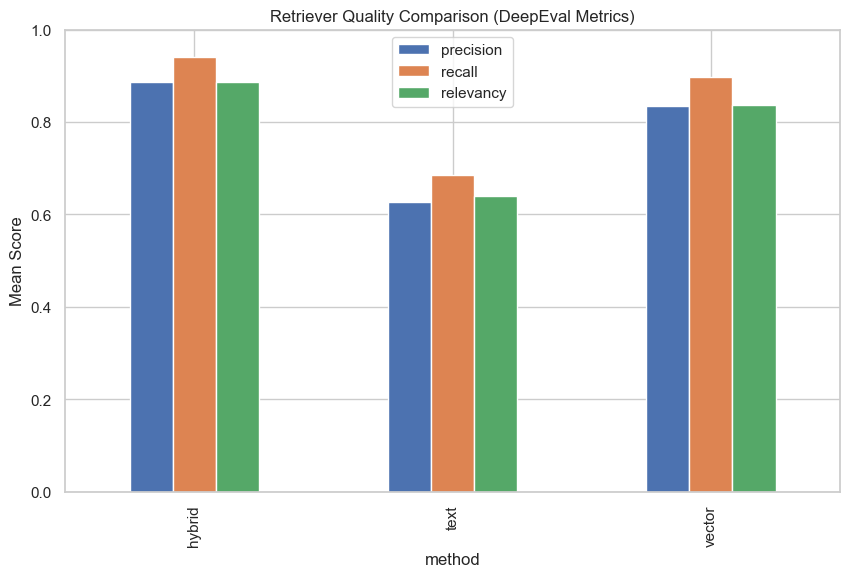

In [44]:
summary.plot(kind="bar")
plt.ylim(0,1)
plt.title("Retriever Quality Comparison (DeepEval Metrics)")
plt.ylabel("Mean Score")
plt.show()


#### Precision vs Recall Scatter

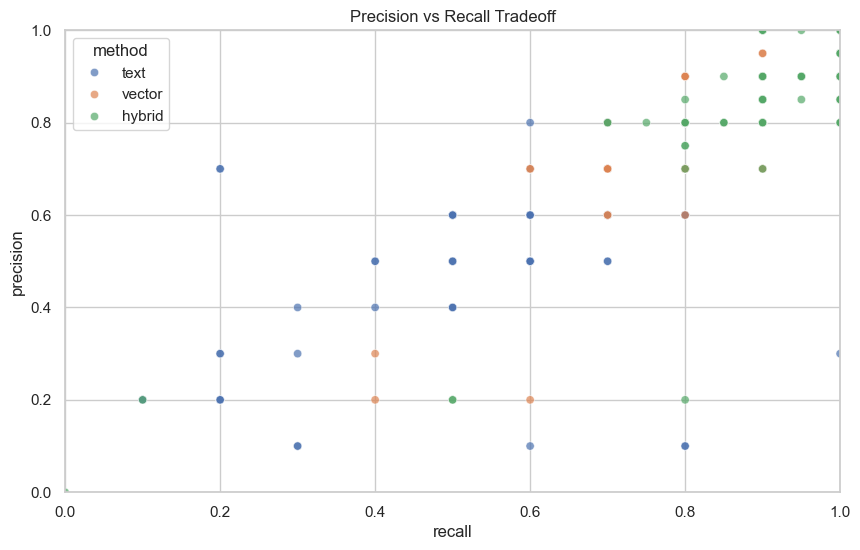

In [45]:

sns.scatterplot(
    data=df,
    x="recall",
    y="precision",
    hue="method",
    alpha=0.7
)

plt.title("Precision vs Recall Tradeoff")
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

#### Distribution plots per metric

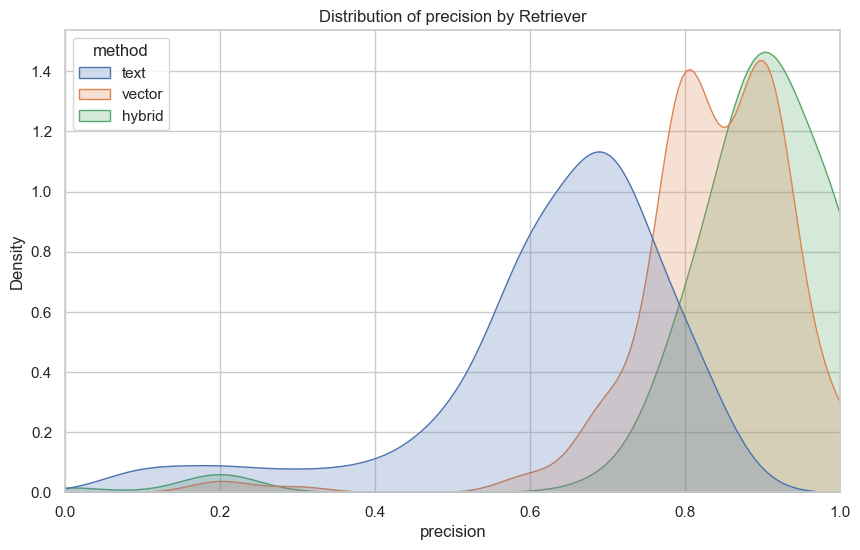

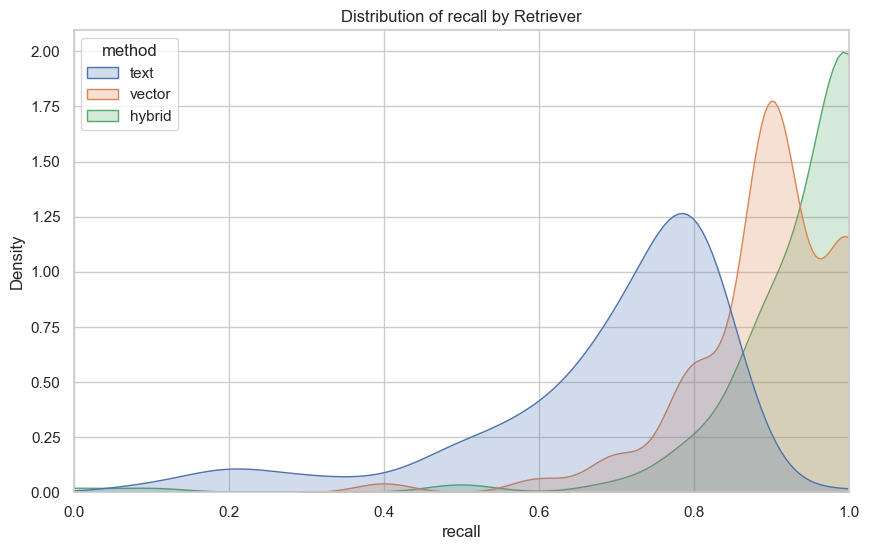

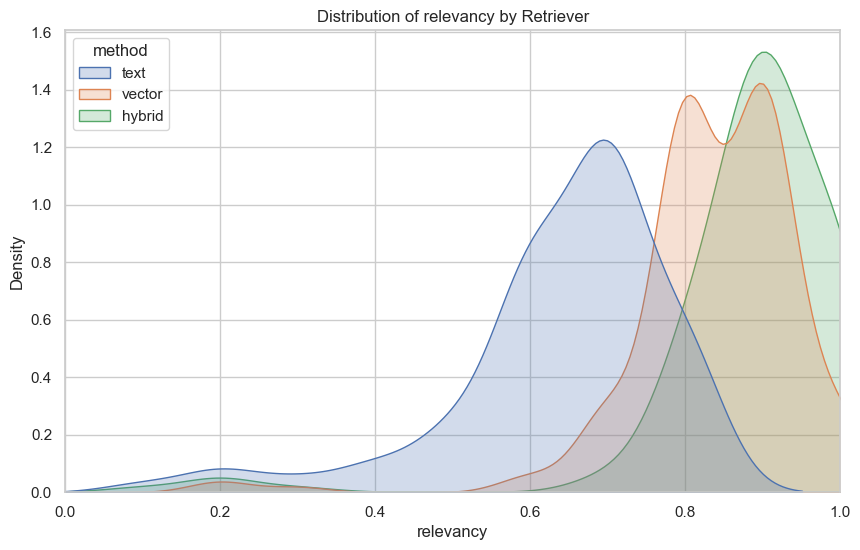

In [46]:
for metric in ["precision","recall","relevancy"]:
    sns.kdeplot(data=df, x=metric, hue="method", fill=True)
    plt.title(f"Distribution of {metric} by Retriever")
    plt.xlim(0,1)
    plt.show()

#### Statistical significance test (ANOVA) 
Tells us if the the mean scores of at least one retriever significantly different from the others

In [47]:
for metric in ["precision","recall","relevancy"]:
    groups = [df[df.method==m][metric] for m in df.method.unique()]
    f,p = stats.f_oneway(*groups)
    print(metric.upper(), "p-value =", round(p,6))

PRECISION p-value = 0.0
RECALL p-value = 0.0
RELEVANCY p-value = 0.0


There is an extremely strong statistical difference in performance between the retrievers for all three metrics.

#### Win-Rate Analysis


In [48]:
winners = []

for _, group in df.groupby("input"):
    best = group.sort_values("relevancy", ascending=False).iloc[0]
    winners.append(best["method"])

winrate = pd.Series(winners).value_counts(normalize=True)
winrate

hybrid    0.707865
vector    0.292135
Name: proportion, dtype: float64

#### Metric Correlation Analysis

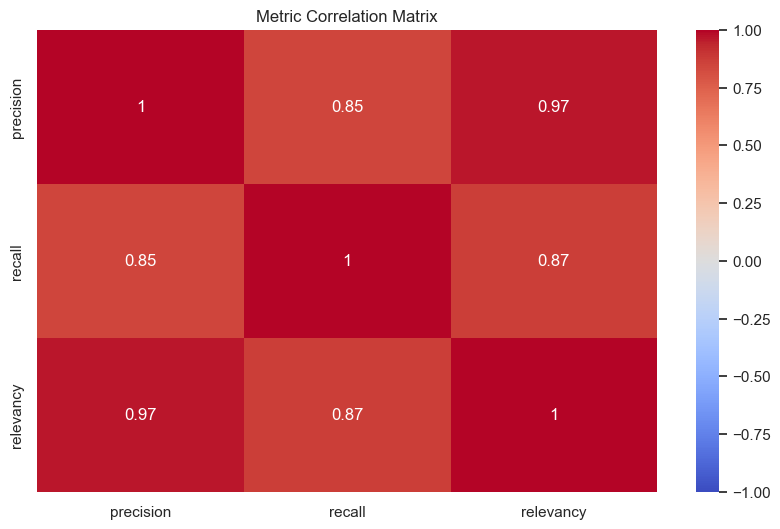

In [49]:
corr = df[["precision","recall","relevancy"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Metric Correlation Matrix")
plt.show()